# Langgraph Chatbot With Tools

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

## 도구 정의

In [3]:
# Tavily Search 도구 생성 및 검색
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)
tavily_tool.invoke('랭그래프의 노드와 엣지가 뭐야?')

{'query': '랭그래프의 노드와 엣지가 뭐야?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://lsjsj92.tistory.com/696',
   'title': '랭그래프(LangGraph)란? LangGraph의 개념과 사용 방법 예제(example)',
   'content': '상태 (State): 그래프의 \'메모리\'입니다. 그래프의 각 단계를 거치면서 데이터가 어떻게 변하고 유지되는지를 정의하는 객체입니다. 대화 기록, 중간 결과, 사용자 정보 등 에이전트가 작업을 수행하는 동안 기억해야 할 모든 정보가 이 상태에 담깁니다. 보통 파이썬의 TypedDict를 사용하여 명확한 구조로 정의합니다.\n 노드 (Nodes): 그래프의 \'작업 단위\'입니다. 특정 작업을 수행하는 Python 함수라고 생각할 수 있습니다. 노드는 현재의 상태(State)를 입력받아, LLM을 호출하거나 도구를 사용하는 등의 작업을 처리한 뒤, 변경된 상태를 반환합니다.\n 엣지 (Edges): 노드와 노드를 연결하는 \'경로\'입니다. 정보와 제어 흐름이 어떤 순서로 이어질지를 결정합니다.\n\n## 예제 코드로 LangGraph 작동 방식 이해하기 [...] 관리 메뉴\n\n 글쓰기\n 방명록\n RSS\n 관리\n\n## 꿈 많은 사람의 이야기\n\n## 랭그래프(LangGraph)란? LangGraph의 개념과 사용 방법 예제(example) 본문\n\n인공지능(AI)/AI Agent\n\n### 랭그래프(LangGraph)란? LangGraph의 개념과 사용 방법 예제(example)\n\n이수진의 블로그 2025. 7. 27. 16:29\n\n반응형\n\n## 포스팅 개요\n\n이번 포스팅에서는 랭체인(LangChain) 생태계의 라이브러리인 랭그래프(LangGraph)에 대해서 알아봅니다. LangGraph란 무엇인지 알아보고, LangG

## 그래프 구성

In [10]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage  # 메시지 타입

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool]
llm_with_tools = llm.bind_tools(tools)  # llm에 도구 스펙 파인딩

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

In [ ]:
from langchain_core.messages import ToolMessage  # 툴 실행 결과를 담을 메시지 타입
import json  # json 문자열 파싱

# tool call을 실행하는 노드 클래스
class ToolNode:
    def __init__(self, tools):
        self.tools_by_name = {tool.name: tool for tool in tools}  # {tool_name: tool 객체}

    def __call__(self, inputs: State):
        """
        도구 호출을 처리하는 메서드입니다.

        Args:
            inputs (dict): 입력 상태 딕셔너리. 'messages' 키에 메시지 리스트가 포함되어야 합니다.

        Returns:
            dict: 도구 실행 결과를 담은 메시지 리스트가 포함된 딕셔너리.
                 형식: {"messages": [ToolMessage, ...]}

        Raises:
            ValueError: 입력에 메시지가 없는 경우 발생합니다.        
        """
        # messages가 있으면 마지막 메시지 가져오고, 아니면 에러발생
        if messages := inputs.get("messages"):
            message = messages[-1]  # 마지막 메시지(AI Message)는 도구 호출 대상
        else:
            raise ValueError("메시지가 없습니다!")

        outputs = []  # ToolMessage 들을 담을 리스트

        # 마지막 메시지(AI Message)에 포함된 tool_calls를 순회
        for tool_call in message.tool_calls:
            # tool 이름을 찾아 실행 (매개변수는 ai메시지에서 전달한 입력매개변수)
            tool_result = self.tool_by_name[tool_call['name']].invoke(tool_call['args'])
            tool_message = ToolMessage(
                content = json.dump(tool_result),  # 결과를 json으로 파싱
                name = tool_call['name'],
                tool_call_id = tool_call['id']
            )
            outputs.append(tool_message)

        return {"messages": outputs}
    

In [ ]:
# 도구 호출 여부에 따른 분기 함수(tools_condition)
# - 다음 분기로 tools로 보낼지 아니면 END로 끝낼지 결정
from pprint import pprint

def tools_condition(state: State):
    pprint(state['messages'])

    if isinstance(state, list):  # state가 list형태(MessageGraph)인 경우
        ai_message = state[-1]  # 마지막 메시지는 AIMessage
    elif messages := state.get("messages", []):  # state가 dict 형태(StateGraph)인 경우
        ai_message = messages[-1]
    else:
        raise ValueError(f"State의 tool_edge에서 들어온 메시지 확인 불가: {state}")

    # AIMessage에 tool_calls가 있으면 도구 노드로 이동
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return 'tools'

    # tool_calls가 없으면 END 노드로 이동
    return END

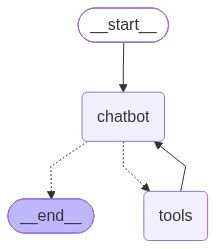

In [7]:
# 직접 구현한 ToolNode와 tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

workflow.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

workflow.add_node('chatbot', chatbot)  # chatbot 노드
workflow.add_node('tools', tool_node)  # tools 노드

workflow.add_conditional_edges('chatbot', tools_condition, {'tools': 'tools', END: END})
workflow.add_edge('tools', 'chatbot')

graph = workflow.compile()  # 설계된 워크프로우를 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

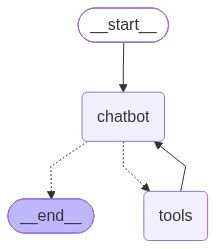

In [8]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

workflow.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

workflow.add_node('chatbot', chatbot)  # chatbot 노드
workflow.add_node('tools', tool_node)  # tools 노드

workflow.add_conditional_edges('chatbot', tools_condition, {'tools': 'tools', END: END})
workflow.add_edge('tools', 'chatbot')

graph = workflow.compile()  # 설계된 워크프로우를 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

In [ ]:
user_query = '랭그래프의 구성요소는?'

state = {'messages': [HumanMessage(content=user_query)]}  # HumanMessage 객체 내 메시지 구현

response = graph.invoke(state)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print("="*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='랭그래프의 구성요소는?', additional_kwargs={}, response_metadata={}, id='abfb0b77-407a-42f4-b22c-84ce2c9ce395'),
              AIMessage(content='랭그래프(LangGraph)의 주요 구성요소는 보통 아래처럼 이해하면 됩니다.\n\n1. **노드(Node)**\n   - 그래프에서 실행되는 개별 작업 단위입니다.\n   - 예: LLM 호출, 도구 사용, 데이터 전처리, 상태 검증 등\n\n2. **엣지(Edge)**\n   - 노드와 노드를 연결하는 실행 경로입니다.\n   - 다음에 어떤 노드로 이동할지 결정합니다.\n\n3. **상태(State)**\n   - 그래프 전체에서 공유되는 데이터입니다.\n   - 각 노드가 입력받고 수정하며, 실행 흐름 중 누적됩니다.\n\n4. **시작/종료 지점**\n   - 그래프의 진입점과 종료 조건입니다.\n   - `START`, `END` 같은 개념으로 표현됩니다.\n\n5. **조건부 엣지(Conditional Edge)**\n   - 상태나 실행 결과에 따라 다음 노드를 동적으로 선택합니다.\n   - 분기 로직에 사용됩니다.\n\n6. **체크포인트/메모리(Checkpointing / Memory)**\n   - 중간 상태를 저장해 재개하거나 대화 맥락을 유지하는 데 사용됩니다.\n\n7. **서브그래프(Subgraph)**\n   - 큰 그래프 안에 포함되는 작은 그래프입니다.\n   - 복잡한 워크플로를 모듈화할 때 유용합니다.\n\n간단히 말하면, **“상태를 공유하는 노드 기반 워크플로 엔진”** 이라고 볼 수 있습니다.\n\n원하시면 제가 이어서\n- **LangChain과 LangGraph 차이**\n- **간단한 LangGraph 예제**\n- **상태(State) 설계 방법**\n도 설명해드릴게요.', additional_kwargs={

In [13]:
user_query = '최근 우리나라의 산불 횟수는?'

state = {'messages': [HumanMessage(content=user_query)]}  # HumanMessage 객체 내 메시지 구현

response = graph.invoke(state)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print("="*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='최근 우리나라의 산불 횟수는?', additional_kwargs={}, response_metadata={}, id='d8527267-086a-4947-8ca6-e41231089884'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 1279, 'total_tokens': 1346, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJqYRol8NUjfCbTvWecdEPR4FChdC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a064e2-7a23-7733-8f9d-83a85b403707-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '대한민국 최근 산불 횟수 최근 연도 산불 발생 건수 산림청 통계', 'include_do